Loading dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Building the AI model...
Training the model (this will take less than a minute)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9122 - loss: 0.3001 - val_accuracy: 0.9558 - val_loss: 0.1428
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9585 - loss: 0.1422 - val_accuracy: 0.9656 - val_loss: 0.1118
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9687 - loss: 0.1061 - val_accuracy: 0.9721 - val_loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9730 - loss: 0.0858 - val_accuracy: 0.9766 - val_loss: 0.0776
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9770 - loss: 0.0743 - val_accuracy: 0.9761 - val_loss: 0.0732
313/313 - 1s - 2ms/step - accuracy: 0.9761 - loss: 0.0732

 Final Test Accuracy: 97.61%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


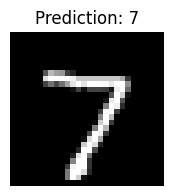

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load and prepare the MNIST dataset (Handwritten digits)
print("Loading dataset...")
mnist = tf.keras.datasets.mnist
(x_train, y_train), \
    (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0.0 and 1.0
x_train, x_test = x_train / 255.0, \
    x_test / 255.0

# 2. Build a simple Neural Network model
print("Building the AI model...")
model = models.Sequential([
    # Flatten the 28x28 images into a 1D array of 784 pixels
    layers.Flatten(input_shape=(28, 28)),
    # Hidden layer with 128 neurons
    layers.Dense(128, activation='relu'),
    # Dropout to prevent overfitting
    layers.Dropout(0.2),
    # Output layer with 10 neurons (one for each digit 0-9)
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
print("Training the model (this will take less than a minute)...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 5. Evaluate the model's final accuracy on unseen data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n Final Test Accuracy: {test_acc * 100:.2f}%")

# 6. Make a quick visual prediction to showcase in your video
plt.figure(figsize=(2,2))
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Prediction: {model.predict(x_test[:1]).argmax()}")
plt.axis('off')
plt.show()